In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# Load dataset
df = pd.read_csv("nobel.csv")

 ANALYSIS PART

In [3]:
top_gender = df['sex'].value_counts().idxmax()
top_country = df['birth_country'].value_counts().idxmax()

print("Top Gender:", top_gender)
print("Top Country:", top_country)

Top Gender: Male
Top Country: United States of America


In [4]:
df['decade'] = (df['year'] // 10) * 10
df['usa_winner'] = df['birth_country'] == "United States of America"
decade_ratio = df.groupby('decade')['usa_winner'].mean()
max_decade_usa = int(decade_ratio.idxmax())

print("Decade with highest US ratio:", max_decade_usa)

Decade with highest US ratio: 2000


In [5]:
df['female'] = df['sex'] == "Female"
female_ratio = df.groupby(['decade', 'category'])['female'].mean()
max_pair = female_ratio.idxmax()
max_female_dict = {int(max_pair[0]): max_pair[1]}

print("Max female proportion:", max_female_dict)

Max female proportion: {2020: 'Literature'}


In [6]:
first_woman = df[df['sex'] == "Female"].sort_values('year').iloc[0]
first_woman_name = first_woman['full_name']
first_woman_category = first_woman['category']

print("First woman:", first_woman_name)
print("Category:", first_woman_category)

name_counts = df['full_name'].value_counts()
repeat_list = name_counts[name_counts > 1].index.tolist()

print("Repeat winners:", repeat_list)

print("\n--- FINAL ANSWERS ---")
print("top_gender =", top_gender)
print("top_country =", top_country)
print("max_decade_usa =", max_decade_usa)
print("max_female_dict =", max_female_dict)
print("first_woman_name =", first_woman_name)
print("first_woman_category =", first_woman_category)
print("repeat_list =", repeat_list)

First woman: Marie Curie, née Sklodowska
Category: Physics
Repeat winners: ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Marie Curie, née Sklodowska', 'Linus Carl Pauling', 'Office of the United Nations High Commissioner for Refugees (UNHCR)', 'John Bardeen', 'Frederick Sanger']

--- FINAL ANSWERS ---
top_gender = Male
top_country = United States of America
max_decade_usa = 2000
max_female_dict = {2020: 'Literature'}
first_woman_name = Marie Curie, née Sklodowska
first_woman_category = Physics
repeat_list = ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Marie Curie, née Sklodowska', 'Linus Carl Pauling', 'Office of the United Nations High Commissioner for Refugees (UNHCR)', 'John Bardeen', 'Frederick Sanger']



VISUALIZATION PART


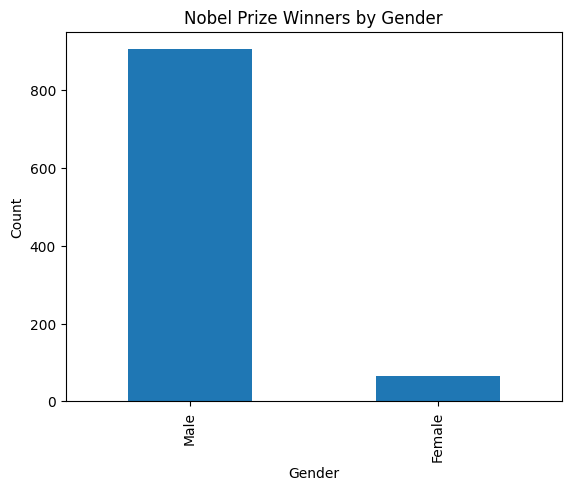

In [7]:
# 1. Gender Distribution
plt.figure()
df['sex'].value_counts().plot(kind='bar')
plt.title("Nobel Prize Winners by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

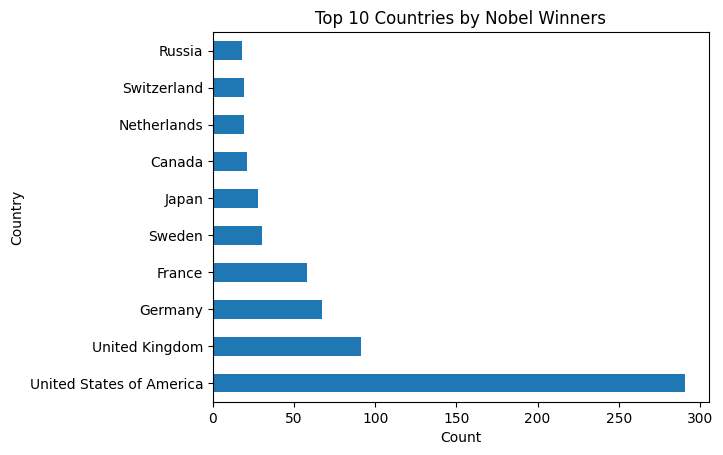

In [8]:
# 2. Top Countries
plt.figure()
df['birth_country'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Countries by Nobel Winners")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

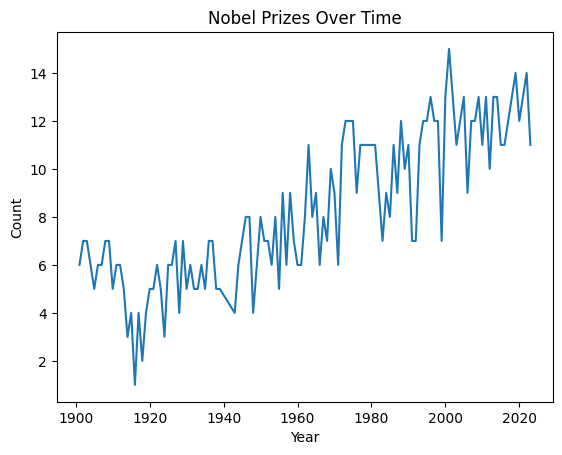

In [9]:
# 3. Nobel Prizes Over Time
plt.figure()
df['year'].value_counts().sort_index().plot(kind='line')
plt.title("Nobel Prizes Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

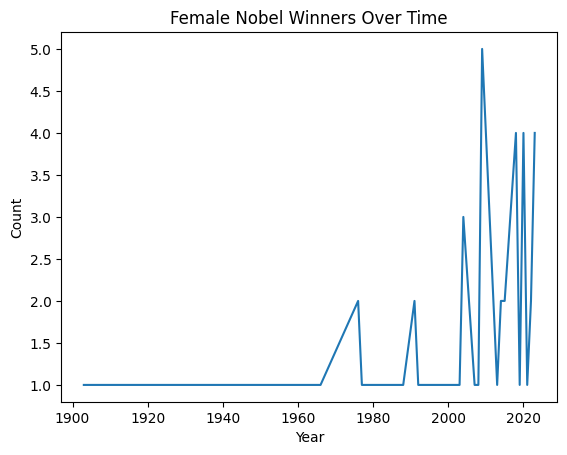

In [10]:
# 4. Female Winners Over Time
plt.figure()
df[df['sex'] == 'Female']['year'].value_counts().sort_index().plot(kind='line')
plt.title("Female Nobel Winners Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

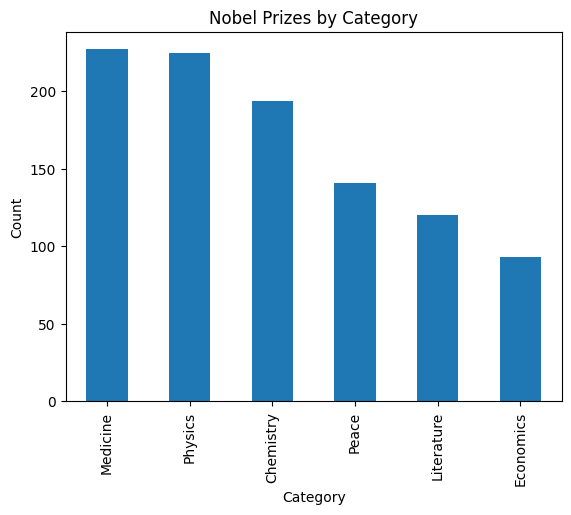

In [11]:
# 5. Category Distribution
plt.figure()
df['category'].value_counts().plot(kind='bar')
plt.title("Nobel Prizes by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


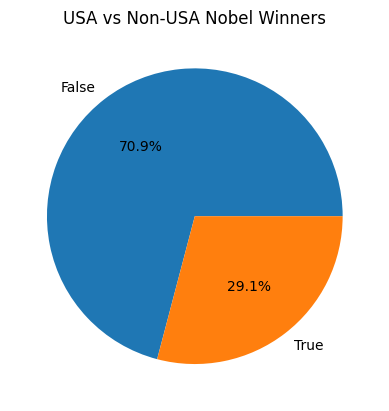

In [12]:
# 6. USA vs Non-USA Winners
plt.figure()
df['usa_winner'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("USA vs Non-USA Nobel Winners")
plt.show()